<a href="https://www.kaggle.com/code/paerle/gpt-2-training-with-vathos?scriptVersionId=285951240" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip uninstall aplos -y
!pip install -q git+https://github.com/MarioPaerle/Aplos.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91

# WikiText103

In [3]:
from Vathos.blocks import *
from Vathos.data import *
from datasets import load_dataset

# Download WikiText-103
dataset = load_dataset("wikitext", "wikitext-103-v1")

# Extract the text into a list needed for Vathos TokenizerWrapper Dataset collator
train_texts = [text for text in dataset['train']['text'] if text.strip()]
val_texts = [text for text in dataset['validation']['text'] if text.strip()]


config = TokenizerConfig(
        model_name="gpt2", # or "bert-base-uncased"
        max_length=2048,
        padding="longest"
)
wrapper = TokenizerWrapper(config)


README.md: 0.00B [00:00, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

# Tiny Stories

from Vathos.blocks import *
from Vathos.data import *
from datasets import load_dataset

# Download TinyStories
dataset = load_dataset("roneneldan/TinyStories")

# Extract the text into a list needed for Vathos TokenizerWrapper Dataset collator
train_texts = [text for text in dataset['train']['text'] if text.strip()]
val_texts = [text for text in dataset['validation']['text'] if text.strip()]

config = TokenizerConfig(
    model_name="gpt2", # or "bert-base-uncased"
    max_length=1024,
    padding="longest"
)
wrapper = TokenizerWrapper(config)

In [4]:
train_loader = wrapper.get_dataloader(train_texts, batch_size=8, shuffle=True)
val_loader = wrapper.get_dataloader(val_texts, batch_size=2, shuffle=False)

Loaded 1165029 texts
Loaded 2461 texts


In [5]:
wrapper.tokenizer.pad_token = wrapper.tokenizer.eos_token
wrapper.tokenizer("<|endoftext|>")

{'input_ids': [50256], 'attention_mask': [1]}

import os
for fl in os.listdir():
    if '-check' in fl:
        os.remove(fl)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

NUM_EPOCHS = 90          
WARMUP_STEPS = 3000      
D_MODEL = 512
BASE_LR = 8e-4   
ADAM_BETA_1 = 0.9
ADAM_BETA_2 = 0.98
ADAM_EPSILON = 1e-8
WEIGHT_DECAY = 0.1      
CLIP_NORM = 1.0
TOKEN_PAD = 50256
model = SequenceModel(
        vocab_size=wrapper.tokenizer.vocab_size,
        d_model=D_MODEL,
        n_layers=8,
        max_len=1024,
        pos_encoder=False,
        rope=True,
        embedder=EasyEmbedder,
        unembedder=UnbiasedLinear,
        channel_mixer=DLPSwiGLU,
        channel_args={'expand': 3},
        spatial_mixer=MultiheadAttentionMixer,
        spatial_args={'n_heads': 8, 'causal':True},
        weight_tying=True,
    ).to(device)
# checkpoint = torch.load("/kaggle/working/-checkpoint.pt", weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
model.load_checkpoint("/kaggle/working/Vathos-GPT2_small-checkpoint.pt")
model.name = 'Vathos-GPT2_small'
model = nn.DataParallel(model).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, betas=(ADAM_BETA_1, ADAM_BETA_2), eps=ADAM_EPSILON, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(ignore_index=TOKEN_PAD)
model.module.summary()
model.module.autosave = True
model.module.autosave_overwrite = True

def get_gpt2_lr_lambda(warmup_steps=WARMUP_STEPS, max_steps=None, min_lr_ratio=0.1):
    """
    GPT-2 style learning rate schedule:
    - Linear warmup from 0 to 1.0 over warmup_steps
    - Cosine decay from 1.0 to min_lr_ratio for remaining steps
    
    Args:
        warmup_steps: Number of warmup steps
        max_steps: Total training steps (if None, will decay indefinitely)
        min_lr_ratio: Minimum LR as a fraction of base LR (default 0.1)
    """
    def lr_lambda(step):
        step = max(step, 1)
        
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        
        if max_steps is None:
            progress = 0
        else:
            progress = float(step - warmup_steps) / float(max(1, max_steps - warmup_steps))
            progress = min(progress, 1.0)
        
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine_decay
    
    return lr_lambda

STEPS_PER_EPOCH = 2500
MAX_STEPS = STEPS_PER_EPOCH * NUM_EPOCHS

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=get_gpt2_lr_lambda(
        warmup_steps=WARMUP_STEPS,
        max_steps=MAX_STEPS,
        min_lr_ratio=0.08  # Decay to 10% of base LR
    )
)

use_amp = True
if use_amp:
    from torch.amp import autocast, GradScaler
    scaler = GradScaler('cuda')

global_step = 0
best_val = float("inf")

VATHOS Model Summary:
SequenceModel(d_model=512, n_layer=8)
	 - Embedder: BasicLayer - O(L d)
	 - Unembedder: BasicLayer - O(L d^2)
	 - Spatial Mixer: MultiheadAttentionMixer({'n_heads': 8, 'causal': True}) - O(L^2 d +  L d^2)
	 - Channel Mixer: DLPSwiGLU({'expand': 3}) - O(L d)
Num Parameters: 53_040_640
Num Trainable Parameters: 53_040_640
Total Complexity: O(L d^2 + L d^2)


In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, betas=(ADAM_BETA_1, ADAM_BETA_2), eps=ADAM_EPSILON, weight_decay=WEIGHT_DECAY)

In [ ]:
from Vathos.training import *

symbolic_1d_ar_input_ids_train(model, train_loader, val_loader, optimizer, scheduler=scheduler, criterion=criterion, device=device, NUM_EPOCHS=16, use_amp=use_amp, spe=STEPS_PER_EPOCH, val_steps=100)

Epoch 1/16 Val:   8%|▊         | 99/1231 [00:02<00:32, 34.68it/s]


Epoch 1 val avg loss: 4.0778


Epoch 2/16 Val:   8%|▊         | 99/1231 [00:02<00:32, 35.00it/s]


Epoch 2 val avg loss: 4.0499


Epoch 3/16 Val:   8%|▊         | 99/1231 [00:02<00:32, 35.01it/s]


...

Epoch 10/16 Val:   8%|▊         | 99/1231 [00:02<00:32, 34.95it/s]


Epoch 10 val avg loss: 4.0293


Epoch 11/16 Val:   8%|▊         | 99/1231 [00:03<00:35, 31.75it/s]


Epoch 11 val avg loss: 4.0225


Epoch 12/16 Train:  63%|██████▎   | 1573/2500 [03:36<02:01,  7.62it/s, loss=4.43, lr=5e-5]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


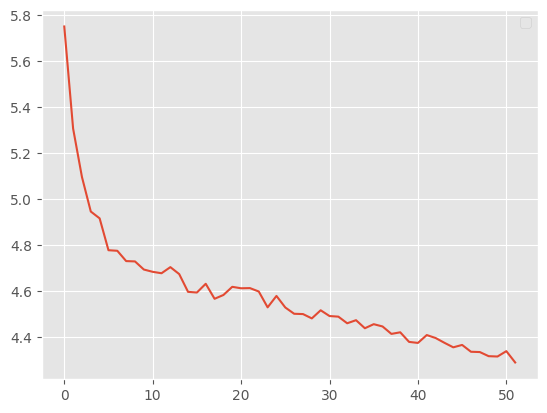

In [10]:
# model.module.plot_losses()
# print(model.module.epochs)
from Vathos.functions import plot
plot(model.module._losses_per_epoch)

In [ ]:
import gc; gc.collect()
torch.cuda.empty_cache()

In [20]:
prompt = "Gabriel is a calabrian horse"
max_len = 100

out = model.module.generate(torch.tensor(wrapper.tokenizer.encode(prompt), device=device), max_len, temperature=0.9, custom_generate=True)
wrapper.decode(out[0])

Fast Gen: 100%|██████████| 99/99 [00:00<00:00, 193.95it/s]


'Gabriel is a calabrian horse @-@ mounted horses , with a large population of 7 @,@ 690 and 6 @,@ 871 . The range is relatively small , with very short , relatively pointed horses , and a large range of animals like the bays , which are long . It is not known to have been found in the same period . The narrow horses are relatively relatively small , with long , broad , wide , small horses and the horses . A grey , long and long , long , short , short'